# Classification of b-quark jets in the Aleph simulated data

The following is an introduction to using Machine Learning (ML).  For this week, we will be using Boosted Decision Trees (BDT) to determine whether if an entry in a data file is of one type (signal, ill, guilty, etc.) or another (background, healthy, innocent, etc.).

You may choose between two datasets:
1. A particle physics dataset containing simulated decays of the $Z^0$ boson decaying to a quark and an anti-quark producing two "jets" of particles. The goal is to determine whether each jet is from a b-quark (b-jet) or from lighter quarks (l-jet).  We will be using this dataset for most of the examples.
2. A simpler "medical" dataset which concers a lifestyle disease in relation to various (transformed) lifestyle variables (reduced in number of variables to match the Aleph b-jet data set).

In the following, we discuss the b-jet problem, as this is where the largest datasets are available. However, we stress that from the point of view of ML, data content (what is being considered) is not essential to know (for now!!!).  Knowing the content in details requires domain knowledge, i.e. expertise in the specific field that the data comes from.  This part is very important, but not the focus for this course.

### The Data:
The input variables (X) are (used by Aleph for their NN):
* **prob_b**: Probability of being a b-jet from the pointing of the tracks to the vertex.
* **spheri**: "Sphericity" of the event (how spherical it is)
* **pt2rel**: The transverse momentum squared of the tracks relative to the jet axis, i.e. width of the jet.
* **multip**: Multiplicity of the jet (in a relative measure).
* **bqvjet**: b-quark vertex of the jet, i.e. the probability of a detached vertex.
* **ptlrel**: Transverse momentum (in GeV) of possible lepton with respect to jet axis (about 0 if no leptons).

Auxilary variables (Z) are (not used by Aleph for their NN, but you are welcome to use them):
* energy: Measured energy of the jet in GeV. Should be 45 GeV, but fluctuates.
* cTheta: cos(theta), i.e. the polar angle of the jet with respect to the beam axis. Note, that the detector works best in the central region (|cTheta| small) and less well in the forward regions.
* phi:    The azimuth angle of the jet. As the Aleph detector was essentially uniform in phi, this should not matter (much).

The target variable (Y) is:
* **isb**:    1 if it is from a b-quark and 0 if it is not.

Finally, those before you (the Aleph collaboration in the mid-90s) produced a Neural Net (6 input variables, two hidden layers with 10 neurons in each, and 1 output varible) based classification variable, which you can compare to (and compete with?):
* **nnbjet**: Value of original Aleph b-jet tagging algorithm, using only the last six variables (for reference).  I have put a link to their paper on the Canvas site in case you are interested.

In case you choose **the medical data**, the variables to use as input (X) are: **Qsocial, BMI, Roccupat, Rgenetic, Rdietary, and Rhormonn** (reflecting Quantiles and Ratios of medical measurements). The target variable (Y) is (naturally): **TrulyIll**, and you can compare your results to the average of doctors: **DocScore**.

### The Task:
Thus, the task before you is to produce functions (non-ML and ML algorithm), which given the input variables X provides an output variable estimate, Y_est, which is "closest possible" to the target variable, Y.  The "closest possible" is left to the user to define in a _Loss Function_, which we will discuss further later.  In classification problems (such as this one), the standard loss function to use is ["Cross Entropy"](https://en.wikipedia.org/wiki/Cross_entropy).

You should approach the problem in two ways:
* Initially (i.e. first 15-30 minutes), simply with "if"-statements making requirements on certain variables.  This corresponds to selecting "boxes" in the input variable space (typically called "X").  One could also try a linear combination of input variables (i.e., a Fisher discriminant), which corresponds to a plane in the X-space.  Such a solution is fast and transparent (very good), but as the data contains non-linear correlations, it is likely to approximate.<br>
**The point of this step is NOT to make a great algorithm, but rather to set up a proper comparison between a "clever" human selection and a ML approach.**

* Next using Machine Learning (ML) methods.  This week we will try a Boosted Decision Tree (BDT) method and see how complicated (or not) it is to get a good solution, and how much better it performs compared with the "classic" selection method.  Next week we will try the same exercise with a Neural Net (NN) approach.

Once you obtain a classification of b-jets vs. l-jets (non-b-jets), think about how to quantify the quality of your algorithm.  Once you have a "metric" for doing so, try to compare it to the NN result of the Aleph collaboration, given by the variable "nnbjet".  It is based on a neural network with 6 input variables (prob_b, spheri, pt2rel, multip, bqvjet, and ptlrel), and two hidden layers each with 10 nodes in.  Can you do better?

You might also draw inspiration from "ML_MethodsDemos.ipynb" (Week 1) or the internet. BDT suggestions might be [XGBoost](https://xgboost.readthedocs.io/en/release_3.0.0/) or [LightGBM](https://lightgbm.readthedocs.io/en/stable/). NN suggestions might be [PyTorch](https://pytorch.org/) or [TensorFlow](https://www.tensorflow.org/).

Last Update: 2026-09-08

In [1]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np

SavePlots = False

## Import and inspect the data:

In [2]:
# Read the data and print the variables:
data = pd.DataFrame(np.genfromtxt('AlephBtag_MC_train_Nev5000.csv', names=True))
# data = pd.DataFrame(np.genfromtxt('Medical_Npatients5000.csv', names=True))

variables = data.columns
print(variables.values)

# Decide on which variables to use for input (X) and what defines the label (Y):
input_variables = variables[(variables != 'nnbjet') & (variables != 'isb') & (variables != 'energy') & (variables != 'cTheta') & (variables != 'phi')]
input_data      = data[input_variables]
truth_data      = data['isb']
benchmark_data  = data['nnbjet']
print("  Variables used for training: ", input_variables.values)

['energy' 'cTheta' 'phi' 'prob_b' 'spheri' 'pt2rel' 'multip' 'bqvjet'
 'ptlrel' 'nnbjet' 'isb']
  Variables used for training:  ['prob_b' 'spheri' 'pt2rel' 'multip' 'bqvjet' 'ptlrel']


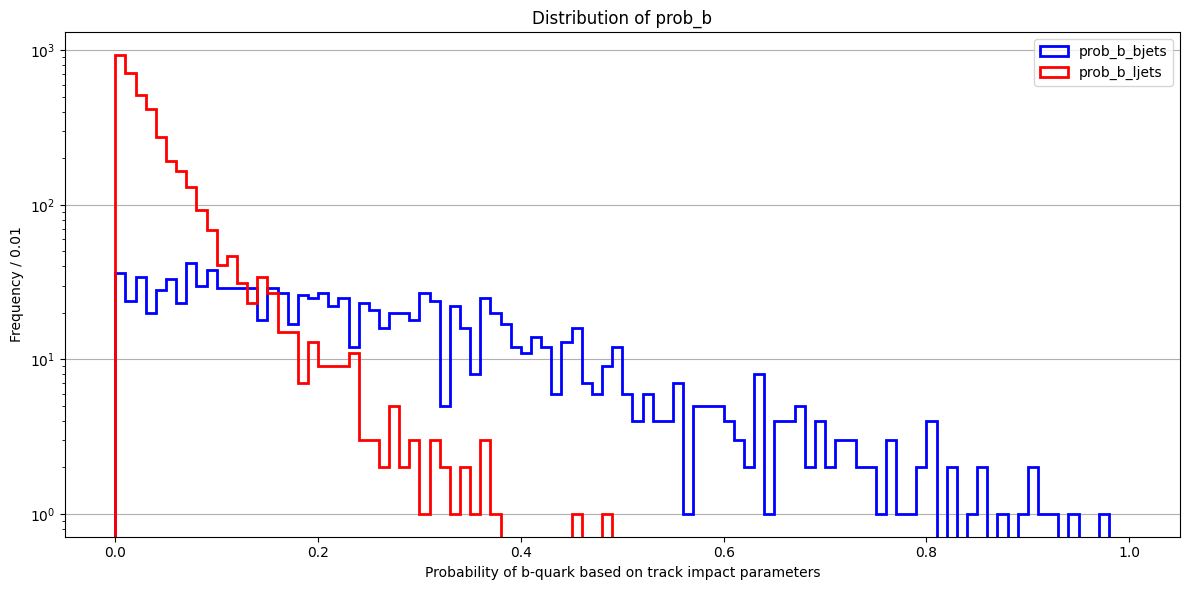

In [3]:
# Look at the distribution of the input variables for each event type:
mask = (data['isb'] == 1)      # Mask to divide the event types

fig, ax = plt.subplots(figsize=(12, 6))
hist_prob_b_bjets = ax.hist(data['prob_b'][mask],  bins=100, range=(0.0, 1.0), histtype='step', linewidth=2, label='prob_b_bjets', color='blue')
hist_prob_b_ljets = ax.hist(data['prob_b'][~mask], bins=100, range=(0.0, 1.0), histtype='step', linewidth=2, label='prob_b_ljets', color='red')
ax.set_xlabel("Probability of b-quark based on track impact parameters")
ax.set_ylabel("Frequency / 0.01")
ax.set_title("Distribution of prob_b")
ax.set_yscale("log")
ax.legend(loc='best')
ax.grid(axis='y')
fig.tight_layout()

if SavePlots :
    fig.savefig('Hist_prob_b.pdf', dpi=600)

## Selection:

Imagine that you had never heard of Machine Learning (ML), and had to select b-jets without! This would probably boil down to doing so simply based on "if"-sentences, as shown below: 

In [4]:
# Give the variables logic names, and define them early, so that they only need to be changed
# in ONE place (also to ensures consistency!):
cut_prop_b  = 0.15

# If prob_b indicate b-quark, call it a b-quark, otherwise not! You can expand on this yourself at will.
bquark=[]
for i in np.arange(len(data['prob_b'])):
    if (data['prob_b'][i] > cut_prop_b) : bquark.append(1)
    else : bquark.append(0)

## Evaluate the selection:

In [5]:
def evaluate(bquark) :
    N = [[0,0], [0,0]]   # Make a list of lists (i.e. confusion matrix) for counting successes/failures.
    for i in np.arange(len(data['isb'])):
        if (bquark[i] == 0 and data['isb'][i] == 0) : N[0][0] += 1
        if (bquark[i] == 0 and data['isb'][i] == 1) : N[0][1] += 1
        if (bquark[i] == 1 and data['isb'][i] == 0) : N[1][0] += 1
        if (bquark[i] == 1 and data['isb'][i] == 1) : N[1][1] += 1
    fracWrong = float(N[0][1]+N[1][0])/float(len(data['isb']))
    accuracy = 1.0 - fracWrong
    return N, accuracy, fracWrong

In [6]:
N, accuracy, fracWrong = evaluate(bquark)
print("\nRESULT OF HUMAN ATTEMPT AT A SELECTION:")
print("  First number in parenthesis is the estimate, second is the MC truth (i.e. label):")
print("  True-Negative (0,0)  = ", N[0][0])
print("  False-Negative (0,1) = ", N[0][1])
print("  False-Positive (1,0) = ", N[1][0])
print("  True-Positive (1,1)  = ", N[1][1])
print("    Fraction wrong            = ( (0,1) + (1,0) ) / sum = ", fracWrong)
print("    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum = ", accuracy)


RESULT OF HUMAN ATTEMPT AT A SELECTION:
  First number in parenthesis is the estimate, second is the MC truth (i.e. label):
  True-Negative (0,0)  =  3673
  False-Negative (0,1) =  443
  False-Positive (1,0) =  149
  True-Positive (1,1)  =  735
    Fraction wrong            = ( (0,1) + (1,0) ) / sum =  0.1184
    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum =  0.8815999999999999


In [7]:
# Compare with Aleph NN-approach from 1990s (choosing a reasonable selection cut on "nnbjet"):
bquark=[]
for i in np.arange(len(data['nnbjet'])):
    if   (data['nnbjet'][i] > 0.82) : bquark.append(1)
    else : bquark.append(0)

N, accuracy, fracWrong = evaluate(bquark)
print("\nALEPH BJET TAG:")
print("  First number in parenthesis is the estimate, second is the MC truth (i.e. label):")
print("  True-Negative (0,0)  = ", N[0][0])
print("  False-Negative (0,1) = ", N[0][1])
print("  False-Positive (1,0) = ", N[1][0])
print("  True-Positive (1,1)  = ", N[1][1])
print("    Fraction wrong            = ( (0,1) + (1,0) ) / sum = ", fracWrong)
print("    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum = ", accuracy)


ALEPH BJET TAG:
  First number in parenthesis is the estimate, second is the MC truth (i.e. label):
  True-Negative (0,0)  =  3700
  False-Negative (0,1) =  372
  False-Positive (1,0) =  122
  True-Positive (1,1)  =  806
    Fraction wrong            = ( (0,1) + (1,0) ) / sum =  0.0988
    Fraction right (accuracy) = ( (0,0) + (1,1) ) / sum =  0.9012


## Questions:

1. Start by plotting the six "Aleph classification variables" and calculate their correlation matrices for signal and background, and see which seems to separate best / correlate most (optional).

2. Above, the scoring is simply done by considering the fraction of wrong estimates.  Think about what the alternatives could be, especially if you were to give a continuous score like the Aleph-NN.  This scoring is called the "loss function".  

3. <b>Draw ROC curves for each of these six variables separately to quantify the separation.  Also draw the Aleph-NN variable (nnbjet).</b> Is the Aleph-NN better?  Are any of the variables "seemingly worthless"? (we will return to this point later).<br>Note that decision variables (i.e. 0 and 1) yield a single point in the ROC curve plot.

4. <b>Try to get a BDT to make predictions based on the six given input variables.  Plot the result on the ROC curve and see if you managed to compete with or even improve upon the Aleph-NN scores.</b>

5. <b>Think about what data you based your predictions on.  Was it the same data that you trained the algorithm on?  And if that is the case, is that reasonable?<b>

6. Does including more data (50000 instead of 5000 events) improve your performance?

7. Does including the kinematic variables 'energy', 'cTheta', and 'phi' (which are not related to jet type) improve your performance?  How do you interpret this?

## Learning points:

From this exercise you should:

1. Get a feel for the problem at hand, namely to separate two populations in a 6-dimensional space.  With simple cuts you should be able to get some performance, though never close to the Aleph-NN.

2. See that it is hard to do this by hand, but that at least the fact that you have known cases (i.e. labels) makes you capable of getting some performance.

3. Be able to draw ROC curves to compare performances between different variables and scores (floating or discrete).

4. See that you can (typically) improve the performance through the use of Machine Learning (ML).

5. <b>Be capable not only of getting ML results, but also confident in optimizing them, and certainly proficient in interpreting them.</b>

---

# Classify B-jets using LightGBM:

The following is a solution example based on LightGBM, which is known to be particularly fast.

## Notes about Boosted Decision Tree solution

The following is a solution based on LightGBM, which is one of the better tree based ML methods. It is imported along with SciKit Learn (sklearn), which has a multitude of ML methods implemented along with a lot of related methods (ROC curve, Area Under Curve (AUC), and Confusion Matrix calculations).

Examples of different LightGBM code solutions can be found here:
* https://github.com/Microsoft/LightGBM/blob/master/examples/python-guide/simple_example.py
* https://www.kaggle.com/code/prashant111/lightgbm-classifier-in-python

Similar solutions can be produced with [XGBoost](https://xgboost.readthedocs.io/en/release_3.0.0/), [CatBoost](https://catboost.ai/), and the new [tabpfn](https://github.com/PriorLabs/TabPFN).

Generally, the steps are:
1. Define the feature (input) and target (output) variables.
2. Define training, validation, and testing samples.
3. Define the loss function (i.e. what it should aim to optimize).
4. Fit for (i.e. train) a model.
5. Apply the model to the test set, and determine performance.

Usually one would apply further checks/regularization/standardization of data before training a model (the latter two in particular for NNs), but this data has already been very nicely "prepared". It won't stay that way!

## LightGBM hyperparameters:

There are several settings that one can run LightGBM with, see this [list of hyperparameters for LightGBM](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html).

[LightGBM] [Info] Number of positive: 872, number of negative: 2878
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000787 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1467
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.232533 -> initscore=-1.194061
[LightGBM] [Info] Start training from score -1.194061
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[76]	train's binary_logloss: 0.214233	valid's binary_logloss: 0.254291
Time used by LightGBM: 107.0 ms
Confusion matrix:
 [[737 207]
 [ 29 277]]


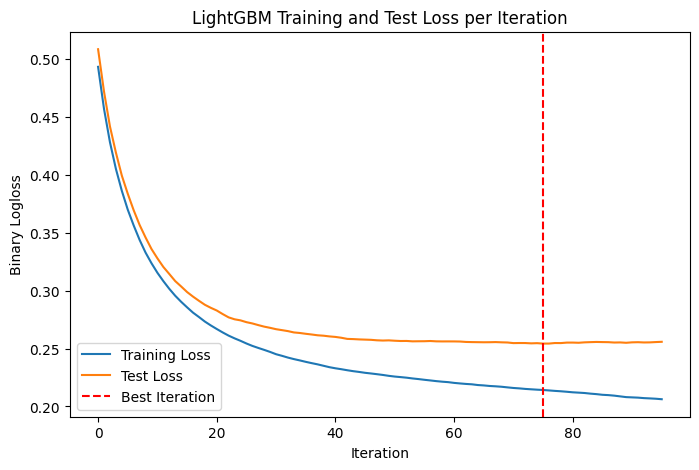

In [8]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
import matplotlib.pyplot as plt
import time

start=time.time()

# Split data set into training and test set. We choose a 75:25 division here. 

# Dataset is shuffled before the split (to avoid any ordering). By using a fixed
# random seed number (42), we can rerun and obtain the same result (for reproducibility!).
input_train, input_test, truth_train, truth_test, benchmark_train, benchmark_test = \
    train_test_split(input_data, truth_data, benchmark_data, test_size=0.25, random_state=42)

# Feed the datasets to LightGBM:
lgb_train = lgb.Dataset(input_train, truth_train)
lgb_eval  = lgb.Dataset(input_test,  truth_test, reference=lgb_train)

# Set parameters for LightGBM (known more generally as "hyper parameters"):
params = {
    'boosting_type': 'gbdt', # Traditional Gradient Boosting tree, we are combining many 'weak' learners here!
    'objective': 'binary',   # The outcome is binary, b-quark or not
    'num_leaves': 6,         # Set a maximum tree leaves to avoid overfitting
    'verbose': 1,            # Level of output. Can be set to -1 to suppress the output
}

# Dictionary to store training results
evals_result_lgb = {}

# Train the model:
gbm_lgb = lgb.train(params,                             # General settings (defined above)
                lgb_train,                          # Data to use for training
                num_boost_round=1000,               # How many rounds for training
                valid_sets=[lgb_train, lgb_eval],  # Track both training and validation
                valid_names=['train','valid'],
                callbacks=[early_stopping(20), lgb.record_evaluation(evals_result_lgb)])  # Stops if no improvement is seen in N=20 rounds.

# Make predictions.
# NOTE the difference between 'score' (continuous in ]0,1[) and 'predictions' (integer: 0 or 1):
# Also NOTE that you can choose where to set the threshold (here set to 0.1)
y_score_lgb = gbm_lgb.predict(input_test, num_iteration=gbm_lgb.best_iteration)  # Scores are floats in the range ]0,1[.
y_pred_lgb  = [1 if pred > 0.1 else 0 for pred in y_score_lgb]                     # Classify b-quark yes or no (for comparison). 

# Confusion matrix
cm_lgb = confusion_matrix(truth_test, y_pred_lgb)

# Print the time usage:
end = time.time()
print(f"Time used by LightGBM: {(end-start)*1000:.1f} ms")

# --- Print summary ---
print("Confusion matrix:\n", cm_lgb)

# --- Plot training & validation loss ---
plt.figure(figsize=(8,5))
plt.plot(evals_result_lgb['train']['binary_logloss'], label='Training Loss')
plt.plot(evals_result_lgb['valid']['binary_logloss'], label='Test Loss')
plt.axvline(gbm_lgb.best_iteration-1, color='r', linestyle='--', label='Best Iteration')
plt.xlabel('Iteration')
plt.ylabel('Binary Logloss')
plt.title('LightGBM Training and Test Loss per Iteration')
plt.legend()
plt.show()


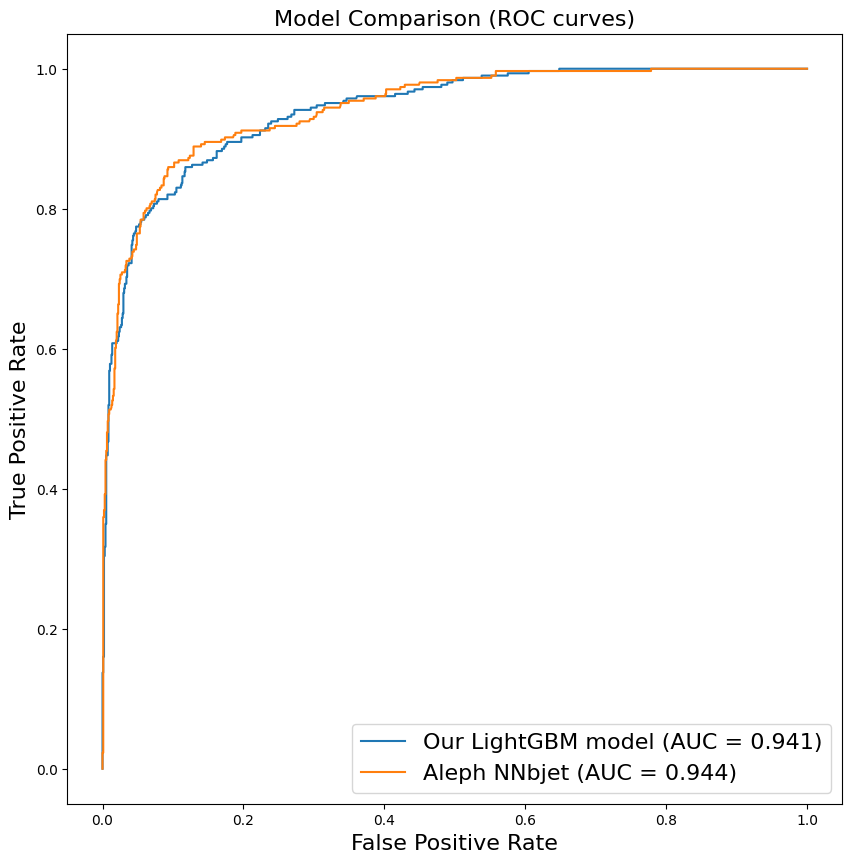

In [9]:
# Evaluate:
fpr, tpr, _ = roc_curve(truth_test, y_score_lgb)                  # False/True Positive Rate for our LightGBM model
fpr_nnbjet, tpr_nnbjet, _ = roc_curve(truth_test, benchmark_test)  # False/True Positive Rate for Aleph NNbjet

# We can now calculate the Area-Under-the-Curve (AUC) scores of these ROC-curves:
auc_score = auc(fpr,tpr)                        # This is the AUC score for our LightGBM model
auc_score_nnbjet = auc(fpr_nnbjet, tpr_nnbjet)  # This is the AUC score for Aleph NNbjet

# Let's plot the ROC curves for these results:
fig = plt.figure(figsize = [10,10])
plt.title('Model Comparison (ROC curves)', size = 16)
plt.plot(fpr, tpr, label=f'Our LightGBM model (AUC = {auc_score:5.3f})')
plt.plot(fpr_nnbjet, tpr_nnbjet, label = f'Aleph NNbjet (AUC = {auc_score_nnbjet:5.3f})')
plt.legend(fontsize=16)
plt.xlabel('False Positive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.show()


## Notes about solution:

The above solution took less than a second to run, works for any number of input variables, and produces a result very close to the one heavily optimized in the 1990s.

Why doesn't it reach (or surpass) the Aleph-NN solution? Well, we have not optimized the performance of the LightGBM algorithm (i.e. optimized the hyper parameters - more to come on that), nor trained it on large amounts of data. Try to do that yourself.

In [ ]:
import time                    # For measuring execution time
import numpy as np             # Numerical operations
import matplotlib.pyplot as plt # Plotting
from sklearn.model_selection import train_test_split  # For splitting dataset into train/test
from sklearn.metrics import confusion_matrix, roc_curve, auc  # Performance metrics
from tensorflow.keras.models import Sequential  # To build feed-forward NN
from tensorflow.keras.layers import Dense, Dropout  # Core layers for NN
from tensorflow.keras.callbacks import EarlyStopping  # To stop training early when validation stops improving
from tensorflow.keras.optimizers import Adam

start = time.time()  # Record start time to measure total training/prediction time

# --- Split dataset ---
input_train, input_test, truth_train, truth_test, benchmark_train, benchmark_test = \
    train_test_split(input_data, truth_data, benchmark_data, test_size=0.25, random_state=42)  
# Randomly split data into 75% training and 25% test set
# random_state=42 ensures reproducibility
# Shuffling avoids bias from any ordering in the original data

# --- Build a feed-forward neural network ---
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(input_train.shape[1],)),  # Fully connected layer with 64 neurons, ReLU activation, input dimension matches number of features
    Dropout(0.2),                                                       # Dropout layer to randomly set 20% of inputs to 0 during training (helps prevent overfitting)
    Dense(32, activation='relu'),                                        # Fully connected layer with 32 neurons, ReLU activation
    Dropout(0.2),                                                       # Another Dropout layer with 20% rate
    Dense(1, activation='sigmoid')                                       # Output layer with 1 neuron, sigmoid activation for binary classification (outputs probability between 0 and 1)
])

# Compile the model
model_nn.compile(
    optimizer=Adam(learning_rate=0.5),              # Adam optimizer for efficient gradient descent
    loss='binary_crossentropy',    # Binary crossentropy loss for binary classification
    metrics=['accuracy']           # Track accuracy during training
)

# Set early stopping
early_stop = EarlyStopping(
    monitor='val_loss',            # Monitor validation loss
    patience=20,                   # Stop if no improvement for 20 epochs
    restore_best_weights=True      # After stopping, restore model to best epoch weights
)

# Train the model
history_nn = model_nn.fit(
    input_train, truth_train,      # Training inputs and labels
    validation_data=(input_test, truth_test),  # Validate on test set
    epochs=1000,                   # Maximum number of epochs to train
    batch_size=1000,                 # Number of samples per gradient update
    callbacks=[early_stop],        # Stop training early if validation loss stops improving
    verbose=1                      # Show training progress
)

# --- Best epoch ---
best_epoch_nn = np.argmin(history_nn.history['val_loss']) + 1  
# Find the epoch with the minimum validation loss
print(f"Best epoch (based on validation loss): {best_epoch_nn}")

# --- Make predictions ---
y_score_nn = model_nn.predict(input_test).flatten()  
# Continuous output probabilities between 0 and 1
y_pred_nn = [1 if pred > 0.1 else 0 for pred in y_score_nn]  
# Threshold = 0.1: classify as 1 if probability exceeds 0.1, else 0

# --- ROC AUC ---
fpr_nn, tpr_nn, thresholds_nn = roc_curve(truth_test, y_score_nn)  
roc_auc_nn = auc(fpr_nn, tpr_nn)  
# Compute Receiver Operating Characteristic curve and Area Under Curve

# --- Confusion matrix ---
cm_nn = confusion_matrix(truth_test, y_pred_nn)  
# Compare predicted vs actual labels

# Print time usage
end = time.time()
print(f"Time used by Neural Network: {(end-start)*1000:.1f} ms")  

# --- Print summary ---
print("Confusion matrix:\n", cm_nn)  #
print(f"ROC AUC: {roc_auc_nn:.3f}")   

# --- Plot training & validation loss ---
plt.figure(figsize=(8,5))
plt.plot(history_nn.history['loss'], label='Training Loss')          # Training loss per epoch
plt.plot(history_nn.history['val_loss'], label='Validation Loss')    # Validation loss per epoch
plt.axvline(best_epoch_nn-1, color='r', linestyle='--', label='Best Epoch')  # Mark best epoch
plt.xlabel('Epoch')                                               
plt.ylabel('Binary Crossentropy Loss')                            
plt.title('Training and Validation Loss per Epoch')               
plt.legend()                                                      
plt.show()  


Epoch 1/1000


C:\Users\cls8dx\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


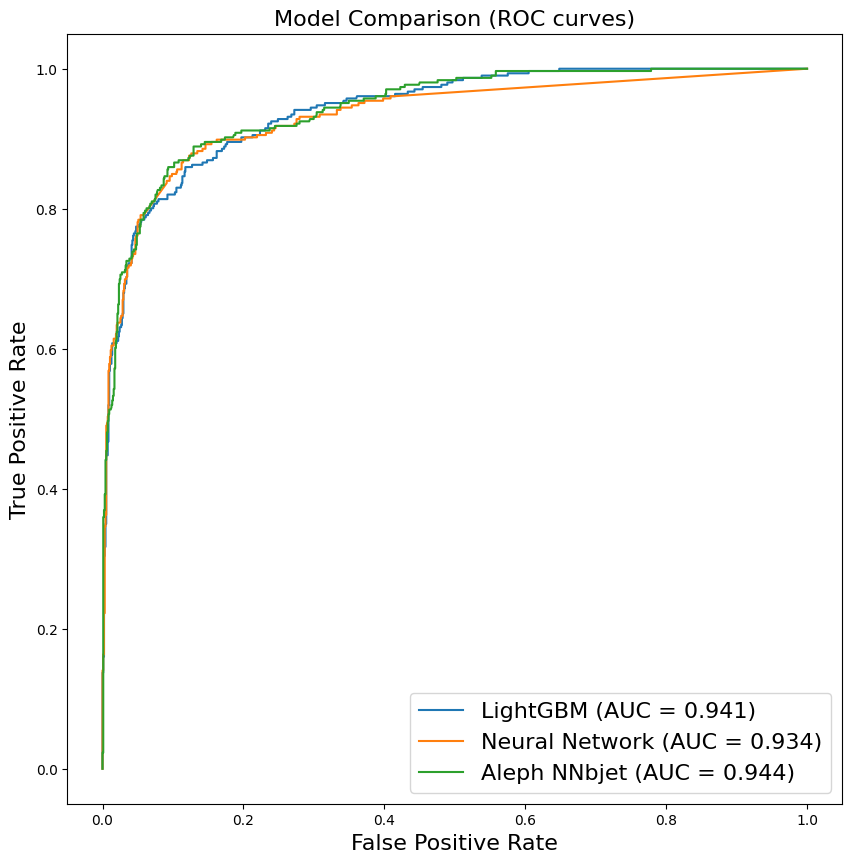

In [45]:
# --- Evaluate ROC for models ---

# LightGBM model predictions:
fpr_lgb, tpr_lgb, _ = roc_curve(truth_test, y_score_lgb)  
# False Positive Rate and True Positive Rate for our LightGBM model

# Neural Network model predictions:
fpr_nn, tpr_nn, _ = roc_curve(truth_test, y_score_nn)  
# False Positive Rate and True Positive Rate for our Neural Network model

# Benchmark predictions (Aleph NNbjet):
fpr_nnbjet, tpr_nnbjet, _ = roc_curve(truth_test, benchmark_test)  
# False/True Positive Rate for the Aleph NNbjet benchmark

# --- Calculate AUC (Area Under the Curve) scores ---
auc_lgb = auc(fpr_lgb, tpr_lgb)              # AUC score for LightGBM
auc_nn = auc(fpr_nn, tpr_nn)                 # AUC score for Neural Network
auc_nnbjet = auc(fpr_nnbjet, tpr_nnbjet)     # AUC score for Aleph NNbjet benchmark

# --- Plot ROC curves for comparison ---
fig = plt.figure(figsize=[10,10])
plt.title('Model Comparison (ROC curves)', size=16)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:5.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:5.3f})')
plt.plot(fpr_nnbjet, tpr_nnbjet, label=f'Aleph NNbjet (AUC = {auc_nnbjet:5.3f})')
plt.legend(fontsize=16)
plt.xlabel('False Positive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.show()
